In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import os
from collections import defaultdict
import matplotlib.pyplot as plt

# ===================== 工具函数（替换Keras Tokenizer） =====================
class SimpleTokenizer:
    def __init__(self, num_words=None, oov_token="<OOV>", filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~'):
        self.num_words = num_words
        self.oov_token = oov_token
        self.filters = filters
        self.word_index = defaultdict(int)
        self.index_word = defaultdict(str)
        self.word_counts = defaultdict(int)
        self.oov_index = 1
        self.vocab_size = 0

    def _clean_text(self, text):
        # 过滤标点符号（和Keras对齐）
        for c in self.filters:
            text = text.replace(c, '')
        return text.lower()  # 统一小写

    def fit_on_texts(self, texts):
        for text in texts:
            text = self._clean_text(text)
            for word in text.split():
                self.word_counts[word] += 1

        sorted_words = sorted(self.word_counts.items(), key=lambda x: x[1], reverse=True)
        if self.num_words:
            sorted_words = sorted_words[:self.num_words - 2]  # 预留0(pad)和1(oov)

        self.word_index[self.oov_token] = self.oov_index
        self.index_word[self.oov_index] = self.oov_token
        idx = 2
        for word, _ in sorted_words:
            self.word_index[word] = idx
            self.index_word[idx] = word
            idx += 1
        self.vocab_size = idx

    def texts_to_sequences(self, texts):
        sequences = []
        for text in texts:
            text = self._clean_text(text)
            seq = []
            for word in text.split():
                seq.append(self.word_index.get(word, self.oov_index))
            sequences.append(seq)
        return sequences

# ===================== 1. 位置编码 =====================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len=512):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        
        # 生成位置编码矩阵
        pos_enc = self._compute_positional_encoding()
        self.register_buffer('pos_enc', pos_enc)  # 不参与训练

    def _compute_positional_encoding(self):
        pos = torch.arange(self.max_seq_len, dtype=torch.float32).unsqueeze(1)  # (max_seq_len, 1)
        i = torch.arange(self.d_model, dtype=torch.float32).unsqueeze(0)       # (1, d_model)
        denominator = torch.pow(10000.0, 2 * (i // 2) / self.d_model)
        
        pos_enc = torch.zeros((self.max_seq_len, self.d_model))
        pos_enc[:, 0::2] = torch.sin(pos / denominator[:, 0::2])  # 偶数维度
        pos_enc[:, 1::2] = torch.cos(pos / denominator[:, 1::2])  # 奇数维度
        return pos_enc

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pos_enc[:seq_len, :].to(x.device)

# ===================== 2. 缩放点积注意力 =====================
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, mask=None):
        # Q: (batch_size, num_heads, seq_len_q, d_k)
        # K: (batch_size, num_heads, seq_len_k, d_k)
        # V: (batch_size, num_heads, seq_len_v, d_v)
        d_k = Q.size(-1)
        
        # 计算QK^T / sqrt(d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1))  # (batch_size, num_heads, seq_len_q, seq_len_k)
        scaled_scores = scores / torch.sqrt(torch.tensor(d_k, dtype=torch.float32)).to(Q.device)
        
        # 应用掩码
        if mask is not None:
            scaled_scores = scaled_scores.masked_fill(mask == 1, -1e9)  # mask=1的位置屏蔽
        
        # Softmax + 与V相乘
        attn_weights = F.softmax(scaled_scores, dim=-1)
        output = torch.matmul(attn_weights, V)
        
        return output, attn_weights

# ===================== 3. 多头注意力 =====================
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        # 线性投影层
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        # x: (batch_size, seq_len, d_model) → (batch_size, num_heads, seq_len, d_k)
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)
        
        # 线性投影
        q_proj = self.w_q(q)
        k_proj = self.w_k(k)
        v_proj = self.w_v(v)
        
        # 拆分多头
        q_split = self.split_heads(q_proj)
        k_split = self.split_heads(k_proj)
        v_split = self.split_heads(v_proj)
        
        # 缩放点积注意力
        attn_output, attn_weights = ScaledDotProductAttention()(q_split, k_split, v_split, mask)
        
        # 拼接多头
        attn_output = attn_output.transpose(1, 2).contiguous()
        concat_output = attn_output.view(batch_size, -1, self.d_model)
        
        # 最终投影
        output = self.w_o(concat_output)
        return output, attn_weights

# ===================== 4. 编码器层 =====================
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        
        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x, mask=None):
        # 多头自注意力 + 残差 + 归一化
        attn_output, _ = self.mha(x, x, x, mask)
        attn_output = self.dropout1(attn_output)
        out1 = self.layernorm1(x + attn_output)
        
        # 前馈网络 + 残差 + 归一化
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)
        out2 = self.layernorm2(out1 + ffn_output)
        
        return out2

# ===================== 5. 解码器层 =====================
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout_rate=0.1):
        super().__init__()
        self.mha1 = MultiHeadAttention(d_model, num_heads)  # 掩码自注意力
        self.mha2 = MultiHeadAttention(d_model, num_heads)  # 编码器-解码器注意力
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        
        self.layernorm1 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm2 = nn.LayerNorm(d_model, eps=1e-6)
        self.layernorm3 = nn.LayerNorm(d_model, eps=1e-6)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.dropout3 = nn.Dropout(dropout_rate)

    def forward(self, x, enc_output, look_ahead_mask=None, padding_mask=None):
        # 掩码自注意力
        attn1, _ = self.mha1(x, x, x, look_ahead_mask)
        attn1 = self.dropout1(attn1)
        out1 = self.layernorm1(x + attn1)
        
        # 编码器-解码器注意力
        attn2, _ = self.mha2(out1, enc_output, enc_output, padding_mask)
        attn2 = self.dropout2(attn2)
        out2 = self.layernorm2(out1 + attn2)
        
        # 前馈网络
        ffn_output = self.ffn(out2)
        ffn_output = self.dropout3(ffn_output)
        out3 = self.layernorm3(out2 + ffn_output)
        
        return out3

# ===================== 6. 完整Transformer =====================
class Transformer(nn.Module):
    def __init__(self, num_layers, d_model, num_heads, d_ff, input_vocab_size,
                 target_vocab_size, max_seq_len=512, dropout_rate=0.1):
        super().__init__()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.d_model = d_model
        self.num_layers = num_layers
        
        # 编码器部分
        self.encoder_embedding = nn.Embedding(input_vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len)
        self.encoder_layers = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout_rate) 
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(dropout_rate)
        
        # 解码器部分：修正层数（与编码器一致）
        self.decoder_embedding = nn.Embedding(target_vocab_size, d_model)
        self.decoder_layers = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout_rate) 
            for _ in range(num_layers)  # 原num_layers//2 → 改为num_layers，6层解码器
        ])
        
        # 输出层
        self.final_layer = nn.Linear(d_model, target_vocab_size)

    def encode(self, x, mask=None):
        seq_len = x.size(1)
        # 词嵌入 + 缩放 + 位置编码
        x = self.encoder_embedding(x) * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32)).to(x.device)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        # 多层编码器
        for layer in self.encoder_layers:
            x = layer(x, mask)
        return x

    def decode(self, x, enc_output, look_ahead_mask=None, padding_mask=None):
        seq_len = x.size(1)
        # 词嵌入 + 缩放 + 位置编码
        x = self.decoder_embedding(x) * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float32)).to(x.device)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        # 多层解码器
        for layer in self.decoder_layers:
            x = layer(x, enc_output, look_ahead_mask, padding_mask)
        return x

    # 其余方法不变，仅修正forward中的掩码传参
    def forward(self, enc_input, dec_input, enc_mask=None, look_ahead_mask=None, dec_padding_mask=None):
        # 编码
        enc_output = self.encode(enc_input, enc_mask)
        # 解码
        dec_output = self.decode(dec_input, enc_output, look_ahead_mask, dec_padding_mask)
        # 输出投影
        final_output = self.final_layer(dec_output)
        return final_output

    #  前瞻掩码（极简版，自动匹配长度）
    def create_look_ahead_mask(self, seq_len):
        mask = torch.triu(torch.ones(seq_len, seq_len, device=self.device), diagonal=1)
        return mask.bool()  # 上三角=需要屏蔽

    #  padding 掩码（极简版）
    def create_padding_mask(self, seq):
        # seq: (batch, seq_len)
        return (seq == 0).unsqueeze(1).unsqueeze(2)  # (batch, 1, 1, seq_len)

In [2]:
# ===================== 数据集处理 =====================
class TranslationDataset(Dataset):
    def __init__(self, enc_input, dec_target):
        self.enc_input = enc_input  # 英语输入 (32)
        self.dec_input = [seq[:-1] for seq in dec_target]  # 解码器输入: 去掉最后一位 (31)
        self.dec_target = [seq[1:] for seq in dec_target]  # 解码器目标: 去掉第一位 (31)

    def __len__(self):
        return len(self.enc_input)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.enc_input[idx], dtype=torch.long),
            torch.tensor(self.dec_input[idx], dtype=torch.long),
            torch.tensor(self.dec_target[idx], dtype=torch.long)
        )

# 读取语料
def read_corpus(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f]
    return lines

# 序列填充
def pad_sequences(sequences, maxlen, padding='post', truncating='post', value=0):
    padded_seqs = []
    for seq in sequences:
        if len(seq) > maxlen:
            if truncating == 'post':
                seq = seq[:maxlen]
            else:
                seq = seq[-maxlen:]
        if len(seq) < maxlen:
            pad_len = maxlen - len(seq)
            if padding == 'post':
                seq += [value] * pad_len
            else:
                seq = [value] * pad_len + seq
        padded_seqs.append(seq)
    return padded_seqs

In [2]:
# ===================== 训练配置 =====================
# 路径配置
DATA_FOLDER = "./de-en"
DE_FILE = "./de-en/europarl-v7.de-en.de"
EN_FILE = "./de-en/europarl-v7.de-en.en"

# 超参数
MAX_VOCAB_SIZE = 30000
MAX_SEQ_LEN = 32
BATCH_SIZE = 32
VAL_SPLIT = 0.1
NUM_LAYERS = 6
D_MODEL = 128
NUM_HEADS = 4
D_FF = 512
DROPOUT_RATE = 0.1
EPOCHS = 2
LEARNING_RATE = 1e-4

# 设备配置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")


使用设备: cuda


In [3]:
# ===================== 修正数据预处理 =====================
# 1. 增强Tokenizer：添加<SOS>/<EOS>/低频词过滤
class EnhancedTokenizer(SimpleTokenizer):
    def __init__(self, num_words=None, oov_token="<OOV>", filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~', 
                 sos_token="<SOS>", eos_token="<EOS>", min_freq=2):
        super().__init__(num_words, oov_token, filters)
        self.sos_token = sos_token
        self.eos_token = eos_token
        self.min_freq = min_freq  # 过滤出现次数<min_freq的词

    def fit_on_texts(self, texts):
        # 第一步：统计词频（过滤低频）
        for text in texts:
            text = self._clean_text(text)
            for word in text.split():
                self.word_counts[word] += 1
        
        # 过滤低频词
        filtered_words = [(w, c) for w, c in self.word_counts.items() if c >= self.min_freq]
        sorted_words = sorted(filtered_words, key=lambda x: x[1], reverse=True)
        
        if self.num_words:
            sorted_words = sorted_words[:self.num_words - 4]  # 预留0(pad)、1(oov)、2(sos)、3(eos)

        # 初始化特殊标记
        self.word_index[self.oov_token] = 1
        self.index_word[1] = self.oov_token
        self.word_index[self.sos_token] = 2
        self.index_word[2] = self.sos_token
        self.word_index[self.eos_token] = 3
        self.index_word[3] = self.eos_token
        
        idx = 4
        for word, _ in sorted_words:
            self.word_index[word] = idx
            self.index_word[idx] = word
            idx += 1
        self.vocab_size = idx

    def texts_to_sequences(self, texts, add_sos_eos=True):
        sequences = []
        for text in texts:
            text = self._clean_text(text)
            seq = []
            for word in text.split():
                seq.append(self.word_index.get(word, self.oov_index))
            # 添加<SOS>/<EOS>
            if add_sos_eos:
                seq = [2] + seq + [3]  # <SOS>=2, <EOS>=3
            sequences.append(seq)
        return sequences

# 2. 修正语料读取（确认德英语料顺序，以Europarl-v7.de-en为例：de是德语，en是英语）
# 任务：英译德 → 输入=英语(en)，输出=德语(de)
de_sentences = read_corpus(DE_FILE)  # 德语（目标）
en_sentences = read_corpus(EN_FILE)  # 英语（输入）

de_sentences = de_sentences[:100000]  # 只取前1万句德语
en_sentences = en_sentences[:100000]  # 只取前1万句英语

# 初始化增强分词器
en_tokenizer = EnhancedTokenizer(num_words=MAX_VOCAB_SIZE, min_freq=3)
en_tokenizer.fit_on_texts(en_sentences)
de_tokenizer = EnhancedTokenizer(num_words=MAX_VOCAB_SIZE, min_freq=3)
de_tokenizer.fit_on_texts(de_sentences)

# 转换序列（添加SOS/EOS）
en_sequences = en_tokenizer.texts_to_sequences(en_sentences)
de_sequences = de_tokenizer.texts_to_sequences(de_sentences)

# 填充序列（目标序列要包含SOS/EOS，max_len=MAX_SEQ_LEN+2 或调整MAX_SEQ_LEN=30+2=32）
en_input = pad_sequences(en_sequences, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
de_output = pad_sequences(de_sequences, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')

# 验证OOV率
def calc_oov_rate(sequences, tokenizer):
    total = 0
    oov = 0
    for seq in sequences:
        for idx in seq:
            if idx == 1:  # OOV索引
                oov += 1
            total += 1
    return oov / total if total > 0 else 0

en_oov = calc_oov_rate(en_sequences, en_tokenizer)
de_oov = calc_oov_rate(de_sequences, de_tokenizer)
print(f"英语OOV率：{en_oov:.2%}，德语OOV率：{de_oov:.2%}")  # 理想<5%，否则调大num_words或降低min_freq

# ===================== 补充：构建DataLoader =====================
# 创建完整数据集
dataset = TranslationDataset(enc_input=en_input, dec_target=de_output)

# 划分训练集和验证集（按VAL_SPLIT比例）
val_size = int(len(dataset) * VAL_SPLIT)
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 创建DataLoader（批量加载数据）
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=0
)

# 打印数据集信息
print(f"总数据量：{len(dataset)} | 训练集：{len(train_dataset)} | 验证集：{len(val_dataset)}")

NameError: name 'read_corpus' is not defined

In [5]:
# ===================== 模型初始化 =====================
en_vocab_size = en_tokenizer.vocab_size
de_vocab_size = de_tokenizer.vocab_size
model = Transformer(
    num_layers=6,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    d_ff=D_FF,
    input_vocab_size=en_vocab_size,
    target_vocab_size=de_vocab_size,
    max_seq_len=MAX_SEQ_LEN,
    dropout_rate=DROPOUT_RATE
).to(device)
model.device = device  # 绑定设备

# ===================== 损失函数和优化器 =====================
# 损失函数：忽略padding（0）
criterion = nn.CrossEntropyLoss(ignore_index=0)

# 3. 修正损失/准确率计算（更高效+稳定）
def compute_loss(logits, labels):
    # logits: (batch_size, seq_len, vocab_size), labels: (batch_size, seq_len)
    # 直接用ignore_index忽略padding，避免手动mask
    loss = F.cross_entropy(
        logits.reshape(-1, logits.size(-1)),
        labels.reshape(-1),
        ignore_index=0,  # padding=0
        reduction='mean'
    )
    return loss

def masked_accuracy(logits, labels):
    mask = (labels != 0)  # 排除padding
    pred = torch.argmax(logits, dim=-1)
    correct = (pred == labels) & mask
    return correct.sum().float() / mask.sum().float() if mask.sum() > 0 else 0.0

# 优化器（遵循Transformer论文参数）
# ===================== 训练策略优化 =====================
# 1. 学习率调度（Transformer论文的warmup策略）
class WarmupLR(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, d_model, warmup_steps=4000, last_epoch=-1):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch + 1
        lr = (self.d_model ** -0.5) * min(step ** -0.5, step * self.warmup_steps ** -1.5)
        return [lr for _ in self.base_lrs]

# 2. 优化器+学习率调度
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0,  # 由调度器动态调整
    betas=(0.9, 0.98),
    eps=1e-9
)
scheduler = WarmupLR(optimizer, d_model=D_MODEL, warmup_steps=4000)

# ===================== 训练函数 =====================
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    total_acc = 0
    
    for enc_in, dec_in, dec_tar in loader:
        enc_in, dec_in, dec_tar = enc_in.to(device), dec_in.to(device), dec_tar.to(device)
        batch_size, dec_seq_len = dec_in.shape  # 这里 dec_seq_len=31

        #  生成正确尺寸的掩码
        enc_mask = model.create_padding_mask(enc_in)
        look_ahead_mask = model.create_look_ahead_mask(dec_seq_len)  # 用31，不是32！
        dec_pad_mask = model.create_padding_mask(dec_in)
        combined_mask = torch.logical_or(look_ahead_mask, dec_pad_mask)

        # 前向传播
        optimizer.zero_grad()
        outputs = model(enc_in, dec_in, enc_mask, combined_mask, enc_mask)
        
        # 损失/准确率
        loss = compute_loss(outputs, dec_tar)
        acc = masked_accuracy(outputs, dec_tar)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        total_acc += acc.item()
    
    return total_loss/len(loader), total_acc/len(loader)

# 验证函数
def val_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for enc_in, dec_in, dec_tar in loader:
            enc_in = enc_in.to(device)
            dec_in = dec_in.to(device)
            dec_tar = dec_tar.to(device)
            
            # 生成掩码
            enc_mask = model.create_padding_mask(enc_in)
            look_ahead_mask = model.create_look_ahead_mask(dec_in.size(1))
            dec_padding_mask = model.create_padding_mask(dec_in)
            look_ahead_mask = torch.max(look_ahead_mask, dec_padding_mask)
            
            # 前向传播
            outputs = model(enc_in, dec_in, enc_mask, look_ahead_mask, enc_mask)
            
            # 计算损失和准确率
            loss = compute_loss(outputs, dec_tar)
            acc = masked_accuracy(outputs, dec_tar)
            
            total_loss += loss.item()
            total_acc += acc.item()
    
    avg_loss = total_loss / len(loader)
    avg_acc = total_acc / len(loader)
    return avg_loss, avg_acc



In [6]:
# ===================== 开始训练 =====================
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\n🚀 开始训练：英语 → 德语 翻译模型")
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 50)
    
    # 训练（添加scheduler）
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    # 验证
    val_loss, val_acc = val_epoch(model, val_loader, device)
    
    # 记录
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"训练损失: {train_loss:.4f}, 训练准确率: {train_acc:.4f}")
    print(f"验证损失: {val_loss:.4f}, 验证准确率: {val_acc:.4f}")


🚀 开始训练：英语 → 德语 翻译模型

Epoch 1/2
--------------------------------------------------
训练损失: 6.3682, 训练准确率: 0.1404
验证损失: 5.3853, 验证准确率: 0.2002

Epoch 2/2
--------------------------------------------------
训练损失: 5.1819, 训练准确率: 0.2144
验证损失: 4.9105, 验证准确率: 0.2408


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_3288/2821484700.py:24: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/

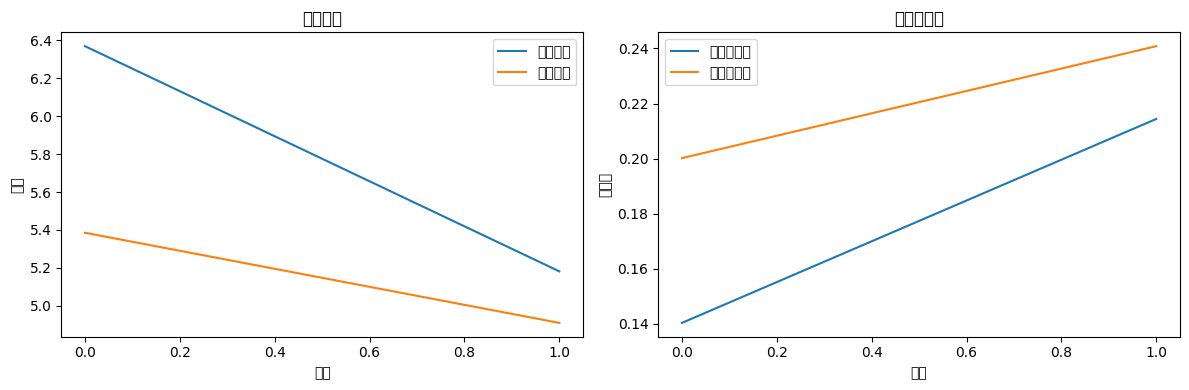


✅ 模型训练完成！权重已保存至：./transformer_de2en_weights.pth


In [7]:
# ===================== 训练结果可视化 =====================
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 4))
# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='训练损失')
plt.plot(val_losses, label='验证损失')
plt.title('损失曲线')
plt.xlabel('轮数')
plt.ylabel('损失')
plt.legend()

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='训练准确率')
plt.plot(val_accs, label='验证准确率')
plt.title('准确率曲线')
plt.xlabel('轮数')
plt.ylabel('准确率')
plt.legend()

plt.tight_layout()
plt.savefig('transformer_train_result.png')
plt.show()

# ===================== 模型保存 =====================
torch.save(model.state_dict(), './transformer_de2en_weights.pth')
torch.save(model, './transformer_de2en_model.pth')
print("\n✅ 模型训练完成！权重已保存至：./transformer_de2en_weights.pth")